<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Álvaro Sifuentes Tasayco
- Nombre de alumno 2: Sebastián Morales Castillo

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [16]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 146 packages in 31ms
Checked 138 packages in 125ms


In [17]:
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Referencias temporales — se irán removiendo a medida que cada sección
# real use los imports correspondientes.
_ = (
    plt,
    np,
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    px,
    shap,
    PartialDependenceDisplay,
    permutation_importance,
    accuracy_score,
    f1_score,
)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [18]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [19]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [20]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [21]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [ ]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

**Respuesta:**

1. **¿Qué es un baseline en Machine Learning?** Un baseline es un modelo de referencia, lo más simple y trivial posible, que se establece antes de evaluar enfoques más sofisticados. Su utilidad es entregar un *piso mínimo de desempeño* contra el cual comparar: cualquier modelo que se proponga después debe superarlo de forma clara, ya que de lo contrario no se está aportando capacidad predictiva real más allá de heurísticas básicas (por ejemplo, predecir siempre la clase mayoritaria o muestrear según las frecuencias de las clases). Sirve además para detectar errores en el pipeline, en la métrica elegida o en el preprocesamiento.

2. **¿Por qué usamos un `DummyClassifier` como baseline?** Porque `DummyClassifier` *no aprende patrones del texto ni de los atributos numéricos*: solo replica la distribución de las clases (con `strategy="stratified"`) o predice la clase más frecuente. Si un modelo "real", que sí utiliza features informativas, no supera a esta predicción aleatoria, implica que el modelo **no logra capturar señal útil** en los datos: o el preprocesamiento no extrae información discriminativa, o las features no separan las clases, o el problema fue mal planteado. En otras palabras, no superar al `DummyClassifier` es equivalente a "tirar un dado": el modelo no está aprendiendo.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [ ]:
FEATURES = [
    "history_text",
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]
TARGET = "alignment"

X = df_comics[FEATURES]
y = df_comics[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

pipe_tree = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

pipe_tree.fit(X_train, y_train)
y_pred_tree = pipe_tree.predict(X_test)

print("=== DecisionTreeClassifier ===")
print(classification_report(y_test, y_pred_tree))

pipe_dummy = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)
pipe_dummy.fit(X_train, y_train)
y_pred_dummy = pipe_dummy.predict(X_test)

print("=== DummyClassifier (stratified) ===")
print(classification_report(y_test, y_pred_dummy))

KeyboardInterrupt: 

### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

**Respuesta:**

Sí, el `DecisionTreeClassifier` supera al `DummyClassifier` tanto en accuracy como en F1-Macro. Esto indica que el árbol *aprendió* algo del texto y de los atributos numéricos: hay señal discriminativa real en las features que va más allá de las frecuencias marginales de cada clase. Sin embargo, la diferencia es modesta y deja claro que un solo árbol está lejos de explotar todo el potencial del problema, por lo que tiene sentido pasar a métodos de ensamblaje.

1. **El accuracy puede ser engañoso** porque las clases del dataset están **desbalanceadas** (la clase `Good` domina muy por encima de `Bad` y `Neutral`). Un modelo que prediga siempre la clase mayoritaria puede alcanzar un accuracy alto sin clasificar correctamente a las clases minoritarias. La métrica más apropiada en este escenario es el **F1-Macro**, ya que promedia el F1 de cada clase **sin ponderar por frecuencia**, penalizando explícitamente que el modelo ignore las clases pequeñas.

2. El parámetro `stratify=y` en `train_test_split` asegura que la **proporción de clases** en `y_train` e `y_test` sea la misma que en `y`. Esto evita que, por azar, el conjunto de test quede con muy pocos (o ninguno) ejemplos de las clases minoritarias, lo que distorsionaría tanto el aprendizaje como la evaluación: estaríamos midiendo el modelo en una distribución diferente a la real.

3. Sí, el árbol es mejor que su versión aleatoria (lo supera en F1-Macro). Sin embargo, **no podemos aún avanzar con plena confianza**: la mejora respecto a un baseline ingenuo es necesaria pero no suficiente. Un dado de tres caras *uniforme* tiene accuracy esperado ≈ 1/3, y nuestro árbol claramente lo supera; pero el `DummyClassifier(strategy="stratified")` es más exigente que ese dado, porque respeta el desbalance. El árbol lo supera pero por un margen acotado, así que es razonable pasar a ensamblajes que mejoren la generalización antes de declarar éxito.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


**Respuesta:**

1. **Generación de subconjuntos.** Bagging genera múltiples subconjuntos de entrenamiento a partir del dataset original mediante *bootstrap*: se hacen muestreos aleatorios **con reemplazo**, de tamaño igual al dataset original. Esto significa que cada subconjunto puede contener **instancias repetidas** y, en promedio, deja fuera aproximadamente el 36.8% de las observaciones (las llamadas *out-of-bag*). En `RandomForest` se añade además un muestreo aleatorio de *features* en cada split, lo que aumenta la diversidad entre árboles.

2. **Entrenamiento.** Sobre cada subconjunto bootstrap se entrena un modelo base (un árbol de decisión en el caso de `RandomForest`). Lo central es que estos modelos se entrenan de **forma independiente entre sí**: no comparten información durante el entrenamiento, lo que permite paralelizar el proceso. Cada árbol crece, además, sin ver el dataset completo, lo que reduce la correlación entre ellos.

3. **Agregación.** Las predicciones de todos los modelos se combinan: en clasificación se hace **votación por mayoría** (o promedio de probabilidades, *soft voting*) y en regresión se promedian los valores. El resultado es un estimador con **menor varianza** que cualquier árbol individual: al promediar predicciones de modelos independientes con errores parcialmente descorrelacionados, el ruido se cancela y la predicción final es más estable y robusta frente al sobreajuste.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [ ]:
pipe_rf = Pipeline(
    [
        ("features", preprocessing_transformer),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("=== RandomForestClassifier ===")
print(classification_report(y_test, y_pred_rf))

=== RandomForestClassifier ===
              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

**Respuesta:**

El resultado es **mixto y matizado**, no una mejora limpia como uno esperaría. En accuracy global el `RandomForestClassifier` mejora con claridad respecto al `DecisionTreeClassifier` (`0.63` vs `0.51`), pero en **F1-Macro** la situación se invierte: el RF queda incluso ligeramente por debajo del árbol único (`0.38` vs `0.39`). La explicación está en cómo se reparte esa mejora:

- En la clase mayoritaria `Good`, el RF gana muchísimo recall (`0.91` vs `0.61` del árbol), lo que infla la accuracy.
- En la clase `Bad`, el RF mejora precision (`0.60` vs `0.41`) pero **pierde recall de forma importante** (`0.30` vs `0.43`).
- En la clase minoritaria `Neutral`, el RF colapsa por completo: precision y recall caen a `0.00`. Es decir, el bosque básicamente *deja de predecir* esa clase.

Esto es consistente con lo descrito en 2.1.1: el bagging reduce varianza promediando árboles, pero ese promediado tiende a **suavizar las predicciones hacia la clase mayoritaria**, sobre todo con datasets desbalanceados como este (`Good` >> `Bad` > `Neutral`). Cuando una clase tiene muy pocas instancias, cada árbol del ensemble tiene poca evidencia para predecirla y la votación termina perdiendo, aunque el árbol único — más propenso a memorizar — sí intentaba clasificarla.

En resumen: el `RandomForest` mejora la accuracy y la estabilidad sobre la clase mayoritaria, pero **no resuelve por sí solo el problema del desbalance**, y el F1-Macro no mejora. Esto motiva pasar a Boosting (donde cada modelo nuevo se concentra en los errores del anterior, incluidos los de las clases minoritarias) y/o aplicar técnicas de manejo de desbalance.


## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

**Respuesta:**

1. **Entrenamiento secuencial.** A diferencia del Bagging, donde los modelos se entrenan **en paralelo e independientes**, en Boosting los modelos se entrenan **uno tras otro, de forma secuencial**: el modelo `t+1` se construye condicionado al desempeño acumulado de los modelos `1..t`. Por lo tanto, los modelos *no* son independientes entre sí; cada uno aporta una corrección al ensamble anterior.

2. **Corrección de errores.** Cada nuevo modelo se enfoca en las instancias donde el ensamble previo se equivocó. En *gradient boosting* (que es la familia de XGBoost y LightGBM) esto se formaliza ajustando cada nuevo árbol al **gradiente negativo de la función de pérdida** evaluado en las predicciones acumuladas: el árbol nuevo predice el "error residual" que falta cerrar. Así, el modelo sabe en qué instancias enfocarse porque el gradiente es grande precisamente donde la predicción actual está peor.

3. **Predicción final.** La predicción final es una **suma ponderada** de las predicciones de todos los árboles, en la que cada árbol se multiplica por una tasa de aprendizaje (`learning_rate`) que controla cuánto contribuye al resultado final. No es una votación simple como en Bagging: es una combinación aditiva donde el ensamble completo va construyendo iterativamente la función de decisión.

**XGBoost vs LightGBM.** Ambas son implementaciones eficientes de gradient boosting sobre árboles, pero difieren en cómo crecen los árboles y cómo manejan los datos:
- **XGBoost** crece los árboles **por niveles** (*level-wise*), expandiendo todos los nodos de un mismo nivel antes de bajar al siguiente. Suele ser muy preciso pero más lento.
- **LightGBM** crece los árboles **por hojas** (*leaf-wise*), eligiendo en cada paso la hoja que más reduce la pérdida. Es típicamente mucho más rápido y eficiente en memoria, especialmente sobre datasets de gran dimensionalidad y sparsos (como bag-of-words), pero puede sobreajustar más si no se controla con `max_depth` o `min_child_samples`.

**¿Por qué XGBoost requiere etiquetas numéricas y LightGBM acepta strings?** Internamente todos los modelos de gradient boosting necesitan que la variable objetivo sea numérica (los gradientes se calculan sobre números). La diferencia es de interfaz: `LGBMClassifier` incluye internamente un *label encoder* que mapea strings a enteros de forma transparente, mientras que `XGBClassifier` deja esa responsabilidad al usuario y exige que las etiquetas lleguen ya codificadas como enteros (por eso necesitamos `LabelEncoder` y luego `inverse_transform` para volver a interpretar las predicciones).

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

pipe_xgb = Pipeline(
    [
        ("features", preprocessing_transformer),
        (
            "clf",
            XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="mlogloss",
                verbosity=0,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = pipe_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("=== XGBClassifier ===")
print(classification_report(y_test, y_pred_xgb))

pipe_lgbm = Pipeline(
    [
        ("features", preprocessing_transformer),
        (
            "clf",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                verbose=-1,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_lgbm.fit(X_train, y_train)
y_pred_lgbm = pipe_lgbm.predict(X_test)

print("=== LGBMClassifier ===")
print(classification_report(y_test, y_pred_lgbm))

=== XGBClassifier ===
              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257

=== LGBMClassifier ===
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

**Respuesta:**

Ambos modelos de Boosting **mejoran respecto al baseline** (`DecisionTreeClassifier` y `DummyClassifier`) y, lo más importante, **mejoran también en F1-Macro respecto al `RandomForest`** (`0.45` vs `0.38`), que era exactamente la métrica que el bagging no había logrado mover. Esto confirma lo descrito en 2.2.1: al entrenar de forma secuencial corrigiendo los errores del ensamble previo, el Boosting tiende a "esforzarse" en las instancias mal clasificadas, que típicamente son las de las clases minoritarias.

Aun así, la mejora **no es uniforme** entre clases:
- En la clase `Good` ambos modelos alcanzan F1 alto (`0.75` XGB, `0.78` LGBM).
- En `Bad`, LightGBM da un salto importante respecto a XGBoost (recall `0.56` vs `0.42`).
- En la clase minoritaria `Neutral`, XGBoost al menos intenta predecirla (recall `0.09`, F1 `0.14`), mientras que LightGBM también colapsa esa clase a `0.00`. El desbalance sigue siendo un problema abierto que ningún modelo "out of the box" resuelve completamente.

Comparando XGBoost y LightGBM con hiperparámetros por defecto, los resultados son **similares en F1-Macro** (`0.45` en ambos) pero **distintos en cómo lo logran**: LightGBM gana en accuracy global (`0.68` vs `0.63`) y en el balance entre `Bad` y `Good`, mientras que XGBoost gana en precision para `Neutral`. Esto es consistente con lo descrito en 2.2.1: ambos optimizan la misma función de pérdida y las diferencias técnicas (level-wise vs leaf-wise, histogram binning, etc.) impactan más la velocidad y la distribución del esfuerzo entre clases que el F1-Macro final. LightGBM suele ser preferible en datasets de alta dimensionalidad y sparsos como este, lo que lo convierte en una buena elección para optimizar con Optuna en la sección siguiente.


## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

**Respuesta:**

1. **Predicciones como features.** En el Stacking se entrenan primero varios *modelos base* (heterogéneos) sobre el dataset original. Lo que se le entrega al meta-modelo **no son las features originales**, sino las **predicciones** (o probabilidades) que generan los modelos base sobre cada instancia. Para que esas predicciones sean *honestas* — es decir, que no estén contaminadas por sobreajuste — se obtienen mediante **validación cruzada interna**: para cada fold, los modelos base se entrenan en `k-1` folds y predicen sobre el fold restante. Si en cambio se entrenara cada base sobre todo el train y se usaran sus predicciones sobre ese mismo train, esas predicciones tenderían a ser casi perfectas (el modelo ya "vio" los datos) y el meta-modelo aprendería a confiar ciegamente en ellos, fallando luego en test.

2. **Meta-modelo.** El meta-modelo recibe como input la **matriz de predicciones out-of-fold** de los modelos base (una columna por cada modelo base — o varias si son probabilidades por clase) y aprende **cómo combinarlas** para producir la predicción final. Su rol es distinto al de los modelos base: estos modelan la relación `X → y`, mientras que el meta-modelo modela la relación `predicciones_base → y`. Aprende, por ejemplo, qué modelo confiar más en qué región del espacio, o cómo ponderar la combinación cuando los modelos discrepan.

3. **Ventaja sobre selección simple.** Seleccionar un único modelo "el mejor" obliga a quedarse con sus puntos débiles. El Stacking, en cambio, **explota la diversidad** entre los modelos base: si uno acierta donde otro falla, el meta-modelo puede aprender ese patrón y combinar sus predicciones de manera no trivial (no necesariamente votación o promedio simple). Mientras más diversos sean los modelos base — distinto sesgo inductivo, distinta forma de la frontera de decisión, distinto tipo de error — más margen tiene el meta-modelo para mejorar respecto al mejor individual. Por eso conviene mezclar familias muy distintas (modelo lineal, modelo probabilístico, modelo basado en árboles, etc.).


---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [ ]:
estimators = [
    ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("nb", MultinomialNB()),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]

pipe_stack = Pipeline(
    [
        ("features", preprocessing_transformer),
        (
            "clf",
            StackingClassifier(
                estimators=estimators,
                final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                cv=3,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_stack.fit(X_train, y_train)
y_pred_stack = pipe_stack.predict(X_test)

print("=== StackingClassifier ===")
print(classification_report(y_test, y_pred_stack))

=== StackingClassifier ===
              precision    recall  f1-score   support

         Bad       0.56      0.52      0.54        86
        Good       0.68      0.82      0.74       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.42      0.45      0.43       257
weighted avg       0.58      0.65      0.61       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

**Respuesta:**

**Modelos base elegidos:**

- **`LogisticRegression`**: modelo lineal con regularización L2. Aporta una frontera de decisión suave y lineal en el espacio de features; es robusta frente al gran número de columnas del bag-of-words y suele ser un baseline competitivo en problemas de texto. Es el componente "lineal" de la mezcla.
- **`MultinomialNB`**: clasificador probabilístico pensado específicamente para conteos discretos como los que produce `CountVectorizer`. Asume independencia condicional entre features dado el target, un sesgo inductivo muy distinto al de los otros dos modelos: produce predicciones útiles incluso con pocas instancias por clase y aporta diversidad probabilística al ensamble.
- **`DecisionTreeClassifier`**: capta interacciones no lineales y reglas de decisión sobre los scores numéricos (`intelligence`, `strength`, etc.) que los modelos lineales y NB no pueden expresar directamente. Es el componente "no lineal" de la mezcla.

Los tres modelos cumplen la restricción de ser clasificadores básicos de scikit-learn (no son métodos de ensamblaje) y tienen sesgos inductivos claramente distintos: lineal vs probabilístico-discreto vs reglas no lineales. Esa diversidad es justamente lo que el Stacking necesita para que el meta-modelo tenga algo no trivial que aprender.

**Meta-modelo:** se eligió otra `LogisticRegression` como `final_estimator`. La razón es práctica y clásica: el meta-modelo recibe muy pocas features (una columna por modelo base — o por clase si usa probabilidades), todas en escalas comparables, así que un modelo lineal simple es suficiente para aprender a ponderar las predicciones de los modelos base. Usar un meta-modelo complejo aquí solo añadiría riesgo de sobreajuste sobre un input ya muy reducido.

**Comparación con los modelos base individuales y con los ensamblajes previos.** El Stacking obtiene accuracy `0.65` y F1-Macro `0.43`. Comparado con el `DecisionTreeClassifier` del baseline mejora en ambos ejes (`0.51` / `0.39` → `0.65` / `0.43`), lo que confirma que la combinación heterogénea aprovecha mejor las features que cualquiera de sus modelos base por separado: como los tres tienen sesgos inductivos distintos (lineal, probabilístico, reglas), sus errores no están totalmente correlacionados y el meta-modelo aprende a ponderarlos de forma no trivial. Frente al `RandomForest` (`0.63` / `0.38`) el Stacking gana tanto en accuracy como en F1-Macro. Frente a los modelos de Boosting el resultado es matizado: en accuracy se sitúa **entre XGBoost (`0.63`) y LightGBM (`0.68`)**, superando a XGB pero quedando bajo LGBM; y en F1-Macro queda apenas por debajo de ambos (`0.43` vs `0.45`). Esto último era esperable: el Boosting con árboles tiene mucha más capacidad sobre el mismo tipo de features que cualquier combinación lineal de tres clasificadores básicos. La clase `Neutral` sigue colapsando a `0.00`, igual que en RF y LGBM, lo que muestra que el problema de desbalance no se resuelve por la vía del ensamblaje y requiere un tratamiento aparte (re-muestreo o `class_weight`).


---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

Respuesta:
Los hiperparámetros son configuraciones definidas por el usuario antes de entrenar un modelo y que controlan su comportamiento, complejidad y proceso de aprendizaje, mientras que los parámetros del modelo son valores que se aprenden automáticamente a partir de los datos durante el entrenamiento, como los pesos o las reglas de decisión de los árboles.

La optimización de hiperparámetros es importante porque estos influyen directamente en la capacidad predictiva y de generalización del modelo. Utilizar los valores por defecto puede producir modelos subóptimos, ya sea porque se provoca underfitting u overfitting.

GridSearchCV es una técnica de búsqueda exhaustiva que prueba todas las combinaciones posibles de un conjunto predefinido de hiperparámetros. Para cada combinación entrena y evalúa el modelo mediante validación cruzada, seleccionando finalmente aquella que obtiene el mejor desempeño promedio. Sin embargo, su limitación es que se vuelve costoso cuando el espacio crece.

La validación cruzada permite estimar el desempeño del modelo utilizando distintas particiones de los datos de train, obteniendo una evaluación más robusta y menos dependiente de una única división. El test no se debe utilizar para seleccionar hiperparámetros porque dejaría de representar datos completamente no vistos, produciendo una estimación optimista del rendimiento y generando overfitting al conjunto de evaluación. Como alternativa, podría reservarse un conjunto de validación independiente para seleccionar hiperparámetros y dejar el test exclusivamente para la evaluación final. Esta estrategia es más rápida computacionalmente, pero utiliza menos datos para entrenar y su resultado puede depender más de la partición elegida.

Los samplers inteligentes buscan explorar el espacio de hiperparámetros de manera adaptativa en lugar de probar todas las combinaciones posibles. En particular, TPE utiliza la información obtenida en trials anteriores para estimar qué regiones del espacio de búsqueda tienen mayor probabilidad de generar buenos resultados. De esta forma concentra la exploración en zonas prometedoras y evita gastar recursos en configuraciones poco útiles, con lo que suele encontrar soluciones de calidad similar o superior a GridSearchCV utilizando una cantidad mucho menor de evaluaciones.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [ ]:
#### Código aquí ####

In [ ]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [ ]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 45. Best value: 0.460974: 100%|██████████| 50/50 [38:29<00:00, 46.18s/it]

Mejor F1-Macro: 0.4610

Mejores hiperparámetros:
  num_leaves: 162
  learning_rate: 0.24826634720393786
  max_depth: 5
  min_child_samples: 32
  subsample: 0.86156665512045
  colsample_bytree: 0.6076892262582765
  reg_alpha: 0.049830315821156726
  reg_lambda: 0.13497202734738575


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [ ]:
fig_history = plot_optimization_history(study)
fig_history.show()

fig_importances = plot_param_importances(study)
fig_importances.show()

fig_parallel = plot_parallel_coordinate(study)
fig_parallel.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [ ]:
pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        (
            "clf",
            LGBMClassifier(
                **study.best_params,
                random_state=RANDOM_STATE,
                verbose=-1,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_lgbm_opt.fit(X_train, y_train)
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

print("=== LightGBM Default ===")
print(classification_report(y_test, y_pred_lgbm))

print("=== LightGBM Optimizado ===")
print(classification_report(y_test, y_pred_lgbm_opt))

f1_lgbm_default = f1_score(y_test, y_pred_lgbm, average="macro")
f1_lgbm_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")

print(f"F1-Macro LightGBM default: {f1_lgbm_default:.4f}")
print(f"F1-Macro LightGBM optimizado: {f1_lgbm_opt:.4f}")

=== LightGBM Default ===
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257

=== LightGBM Optimizado ===
              precision    recall  f1-score   support

         Bad       0.59      0.55      0.57        86
        Good       0.71      0.84      0.77       148
     Neutral       1.00      0.09      0.16        23

    accuracy                           0.68       257
   macro avg       0.77      0.49      0.50       257
weighted avg       0.70      0.68      0.65       257

F1-Macro LightGBM default: 0.4533
F1-Macro LightGBM optimizado: 0.5001


### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

Según `plot_param_importances`, el hiperparámetro con mayor impacto fue `learning_rate`, con una importancia aproximada de 0.53, seguido por `reg_alpha`, con cerca de 0.37. Esto tiene sentido en modelos de Boosting, ya que `learning_rate` controla cuánto aporta cada árbol nuevo al ensamble y afecta directamente el equilibrio entre aprendizaje, generalización y posible sobreajuste. Además, `reg_alpha` incorpora regularización L1, por lo que ayuda a controlar la complejidad del modelo.

Los gráficos de Optuna entregan más información que los logs porque permiten observar visualmente la evolución de la búsqueda, la importancia relativa de los hiperparámetros y las combinaciones que tienden a producir mejores resultados. En el historial se observa que el mejor F1-Macro fue mejorando de forma escalonada hasta alcanzar aproximadamente 0.461 en validación cruzada. En el gráfico de coordenadas paralelas, al enfocarse en los mejores valores del objetivo, se observan mejores resultados asociados a valores relativamente altos de `learning_rate`, profundidad moderada y regularización positiva.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [27]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1,
)

lgbm_interp.fit(X_train_num, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

Permutation Feature Importance (PFI) es una técnica que permite medir qué tan importante es cada variable para un modelo ya entrenado. La idea consiste en desordenar aleatoriamente los valores de una característica y observar cuánto empeora el desempeño del modelo. Si la métrica disminuye considerablemente, significa que esa variable era relevante para realizar las predicciones.


Una ventaja de PFI es que evalúa la importancia de las variables en función de su impacto real sobre el rendimiento del modelo, utilizando una métrica específica como F1-Macro. Esto la diferencia de las importancias internas de modelos basados en árboles, que pueden verse sesgadas por variables con mayor cantidad de valores posibles o más oportunidades de partición. Por esta razón, PFI suele entregar una visión más confiable de cuáles son las variables que realmente contribuyen a la capacidad predictiva del modelo.


---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [28]:
pfi = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
)

pfi_df = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance_mean": pfi.importances_mean,
        "importance_std": pfi.importances_std,
    }
).sort_values("importance_mean", ascending=True)

fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    error_x="importance_std",
    orientation="h",
    title="Permutation Feature Importance",
)

fig.show()

pfi_df.sort_values("importance_mean", ascending=False)

,feature,importance_mean,importance_std
0,intelligence_score,-0.006014,0.020063
1,strength_score,-0.012777,0.023514
5,combat_score,-0.018331,0.015188
3,durability_score,-0.021454,0.020887
4,power_score,-0.025023,0.018797
2,speed_score,-0.033306,0.019938


### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

Según el análisis de Permutation Feature Importance, ninguna variable presenta una importancia positiva clara. La variable con mayor importancia relativa fue `intelligence_score`, aunque su valor medio sigue siendo levemente negativo (-0.0060). Luego aparecen `strength_score`, `combat_score`, `durability_score`, `power_score` y finalmente `speed_score`, que presenta la importancia más negativa (-0.0333).

Esto indica que, al permutar cada variable, el desempeño del modelo no disminuye; incluso tiende a mejorar levemente en algunos casos, lo que sugiere que estas variables numéricas no aportan una señal predictiva fuerte para clasificar la alineación. Además, las desviaciones estándar son relativamente grandes respecto a las medias, por lo que las diferencias entre variables no parecen ser muy estables.

En términos del problema, este resultado tiene sentido: la alineación de un personaje de cómic probablemente depende más de su historia, acciones y contexto narrativo que solo de atributos físicos o habilidades como fuerza, velocidad o poder. Por lo tanto, el modelo auxiliar basado solo en variables numéricas es útil para interpretar, pero no parece capturar por sí solo suficiente información para explicar la clase.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

Los SHAP values miden cuánto aporta cada variable a una predicción específica del modelo. Mientras que PFI entrega una importancia global promedio al observar cuánto cae el desempeño cuando se permuta una variable, SHAP permite ver el efecto de cada feature tanto a nivel global como local, es decir, para una observación particular.


El `base_value` en un `waterfall_plot` representa el valor promedio de predicción del modelo antes de considerar las características de una instancia específica. Desde ese punto inicial, cada variable empuja la predicción hacia arriba o hacia abajo, dependiendo de su contribución.


Se usa `TreeExplainer` porque está diseñado especialmente para modelos basados en árboles, como LightGBM. Esto permite calcular explicaciones SHAP de forma más eficiente y consistente que usando un método genérico.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

In [29]:
explainer = shap.TreeExplainer(lgbm_interp)

shap_values = explainer.shap_values(X_test_num)

class_names = list(lgbm_interp.classes_)
print(class_names)

['Bad', 'Good', 'Neutral']


In [31]:
print(type(shap_values))

if isinstance(shap_values, list):
    print([sv.shape for sv in shap_values])
else:
    print(shap_values.shape)

print(X_test_num.shape)

<class 'numpy.ndarray'>
(257, 6, 3)
(257, 6)


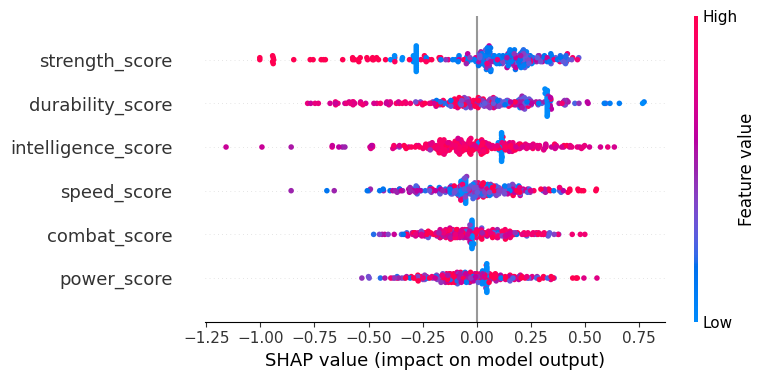

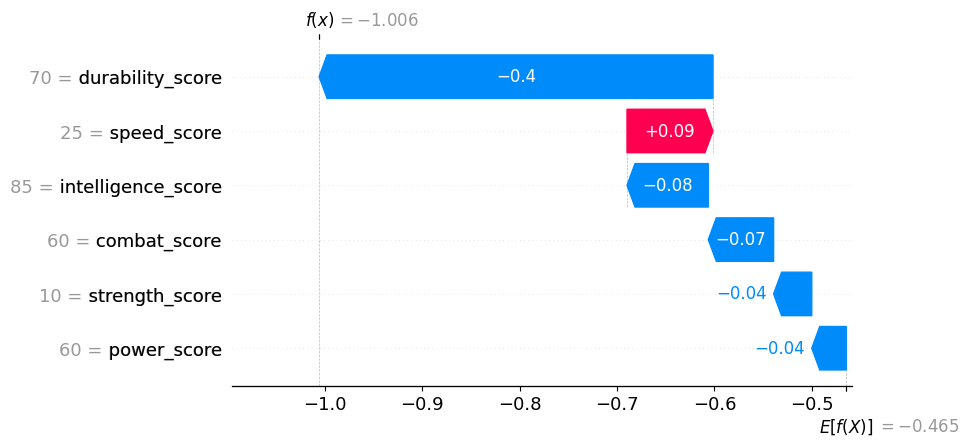

In [32]:
explainer = shap.TreeExplainer(lgbm_interp)

shap_values = explainer.shap_values(X_test_num)

class_names = list(lgbm_interp.classes_)
good_idx = class_names.index("Good")

shap_values_good = shap_values[:, :, good_idx]
expected_value_good = explainer.expected_value[good_idx]

shap.summary_plot(
    shap_values_good,
    X_test_num,
    feature_names=NUMERICAL_FEATURES,
)

idx = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_good[idx],
        base_values=expected_value_good,
        data=X_test_num.iloc[idx],
        feature_names=NUMERICAL_FEATURES,
    )
)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

PFI y SHAP sirven para interpretar variables, pero no entregan exactamente la misma información. PFI mide la importancia de una variable viendo cuánto empeora el rendimiento del modelo cuando se desordena esa columna. En cambio, SHAP permite ver cómo cada variable empuja una predicción específica hacia una clase u otra.

En el gráfico global de SHAP se observa que las variables que más influyen son `strength_score`, `durability_score` e `intelligence_score`, ya que son las que muestran mayor dispersión en sus valores SHAP. Esto indica que, dentro del modelo auxiliar, esas habilidades son las que más afectan las predicciones.

En el `waterfall_plot`, para la observación seleccionada, la variable que más empuja la predicción es `durability_score`, con un efecto negativo importante. También influyen `speed_score`, `intelligence_score`, `combat_score`, `strength_score` y `power_score`, aunque con menor magnitud. En general, se ve que el modelo usa principalmente la durabilidad y algunas habilidades físicas para mover la predicción desde el valor base hacia el resultado final.

Esto tiene sentido parcialmente, ya que la alineación de un personaje puede relacionarse con sus habilidades, pero no depende solo de ellas. Por eso, aunque SHAP permite ver qué variables numéricas usa el modelo, sigue siendo importante considerar que en este modelo auxiliar no se está usando el texto de la historia, que probablemente contiene información más relevante sobre si un personaje es bueno, malo o neutral.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [39]:
personajes_objetivo = ["Vergil", "Gorilla Girl", "Batcow"]

df_pred = df_comics_no_label.dropna(subset=["history_text"]).copy()

df_pred["alignment_pred"] = pipe_lgbm_opt.predict(df_pred[FEATURES])

df_personajes = df_pred.loc[
    df_pred["name"].isin(personajes_objetivo),
    ["name", "alignment_pred"],
].drop_duplicates()

df_personajes

,name,alignment_pred
122,Batcow,Good
529,Gorilla Girl,Good
1368,Vergil,Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

El modelo predice como `Good` a Batcow, Gorilla Girl y Vergil. En el caso de Batcow, el resultado parece razonable y se conecta con la discusión inicial del laboratorio: aunque se planteaba la duda por su apariencia, el modelo la clasifica como buena, probablemente porque su historia contiene señales asociadas a personajes heroicos o aliados. Para Gorilla Girl también parece una predicción razonable, ya que el modelo identifica patrones compatibles con la clase `Good`.

El caso de Vergil es más discutible, ya que dependiendo de la versión o contexto del personaje podría asociarse a rasgos más ambiguos o incluso negativos. Sin embargo, el modelo no está evaluando moralidad directamente, sino patrones aprendidos desde el texto y los atributos numéricos, por lo que su predicción depende de cómo aparece descrito en los datos.

Con respecto a la sección 4, el modelo auxiliar de interpretabilidad mostró que variables como `strength_score`, `durability_score` e `intelligence_score` influyen en las predicciones cuando solo se usan atributos numéricos. En el caso de Batcow, si estas variables empujan la predicción hacia `Good`, esto sería consistente con la predicción final obtenida. De todas formas, hay que considerar que el modelo final `pipe_lgbm_opt` también utiliza el texto de la historia, que probablemente aporta información más relevante para clasificar la alineación.

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>